In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch
import wandb
import matplotlib.pyplot as plt
import glob
import os

import sys
sys.path.append("../")
sys.path.append("../../recurrently_predicting_hypergraphs/")

from utils.dataset import HyperGraphDataset
from metrics import LAP_loss
from train import get_config, main

# Loading

In [3]:
base_path = "/storage/agrp/dreyet/Hypergraphs/hypergraphflow/configs/"

dataset_names = [
    "convex_hull_normal_3D_30to30",
    "convex_hull_normal_3D_20to100",
    "convex_hull_normal_3D_50to50",
    "convex_hull_spherical_3D_20to100",
    "convex_hull_spherical_3D_30to30",
    "convex_hull_spherical_3D_50to50",
]

dataset_configs = [f"{base_path}{dataset}.yaml" for dataset in dataset_names]

In [4]:
def get_ckpt_path(dataset, expID):
    pattern = f"../{dataset}/{expID}/checkpoints/epoch*/val*.ckpt"
    ckpt_path = glob.glob(pattern)
    if len(ckpt_path) == 0:
        raise ValueError(f"No checkpoints matching pattern: {pattern}")
    elif len(ckpt_path) > 1:
        raise NotImplementedError(f"Multiple checkpoints matching pattern: {pattern}.")
    return os.path.abspath(ckpt_path[0])

In [5]:
### Experiment IDs
refiner_experiments = {
    "convex_hull_spherical_3D_20to100": "lj81co6g",
    "convex_hull_spherical_3D_50to50": "nrw2v8l5",
    "convex_hull_normal_3D_20to100": "1hrog24v",
    "convex_hull_normal_3D_50to50": "j9jp4t8w",
    "convex_hull_spherical_3D_30to30": "bblzv2tj",
    "convex_hull_normal_3D_30to30": "njbf03of",
}

'''
hgflow_experiments = {
    "convex_hull_spherical_3D_20to100": "71r6bgww",
    "convex_hull_spherical_3D_50to50": "eaht6kt2",
    "convex_hull_normal_3D_20to100": "5daqp4h4",
    "convex_hull_normal_3D_50to50": "ywmxchek",
    "convex_hull_spherical_3D_30to30": "405su2cw",
    ### "convex_hull_normal_3D_30to30": "rpy6nq6q",
    # "convex_hull_normal_3D_30to30": "xqrmq8rz",
}
'''

### use_im_attn_mask=False and no inc_t residual connection (i.e. no connection to previous time step)
hgflow_experiments = {
    "convex_hull_spherical_3D_20to100": "bciedsrv",
    "convex_hull_spherical_3D_50to50": "q8dlilsl",
    "convex_hull_normal_3D_20to100": "0gsaolif",
    "convex_hull_normal_3D_50to50": "lclp66tn",
    "convex_hull_spherical_3D_30to30": "4ohoaivn",
    "convex_hull_normal_3D_30to30": "q2wpxzy7",
}

### Checkpoints
refiner_ckpts = {dataset: get_ckpt_path(dataset, refiner_experiments[dataset]) for dataset in dataset_names}
hgflow_ckpts = {dataset: get_ckpt_path(dataset, hgflow_experiments[dataset]) for dataset in dataset_names}

In [6]:
dataset = "convex_hull_normal_3D_30to30"
config_dataset = f"../configs/{dataset}.yaml"

# config_model = "../configs/refiner.yaml"
# config_model = "../configs/hgflow.yaml"
config_model = "../configs/hhrm.yaml"
if 'refiner' in config_model:
    ckpt = refiner_ckpts[dataset]
elif 'hgflow' in config_model:
    ckpt = hgflow_ckpts[dataset]
else:
    ckpt = None

config_train = "../configs/train.yaml"

config = get_config(config_train, config_model, config_dataset)

In [7]:
config['accelerator'] = 'cpu'
config['devices'] = 1
config['num_epochs'] = 2000
config['dl_train']['total_size'] = 1
config['dl_train']['batch_size'] = 1

In [8]:
trainer, model, ds, dls = main(config, mode="train", overtrain=True) #, checkpoint=ckpt)

Seed set to 123456


Generated dataset convex_hull_normal_3D_30to30 with 4001 examples, 
max nodes: 30, max edges: 40
Splits: train, val, test           with sizes: 1, 2000, 2000


wandb: Currently logged in as: etienne-dreyer (etienne-dreyer-weizmann-institute-of-science) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: WARNING No relevant files were detected in the specified directory. No code will be logged to your run.
GPU available: True (cuda), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/pytorch_lightning/trainer/setup.py:177: GPU available but not used. You can set it by doing `Trainer(accelerator='gpu')`.


# Training

In [9]:
trainer.fit(model, dls['train'], dls['val'])


  | Name | Type | Params | Mode 
--------------------------------------
0 | net  | HHRM | 663 K  | train
--------------------------------------
663 K     Trainable params
0         Non-trainable params
663 K     Total params
2.654     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:475: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=31` in the `DataLoader` to improve performance.
/usr/wipp/conda/24.5.0u/envs/common/lib/python3.11/site-packages/pytorch_lightning/loop

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=2000` reached.


In [10]:
# for layer in model.net.SA_L:
#     print(layer.alpha_attn)

# for layer in model.net.SA_H:
#     print(layer.alpha_attn)

# Evaluation

In [11]:
metrics = trainer.validate(model, dataloaders=dls['test'])

Validation: |          | 0/? [00:00<?, ?it/s]

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃      Validate metric      ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│          f1/val           │    0.4399999976158142     │
│       logit_max/val       │     1.024137020111084     │
│      logit_mean/val       │   -0.11517395824193954    │
│       logit_min/val       │    -1.1945139169692993    │
│       logit_std/val       │    0.23780977725982666    │
│         loss/val          │    1.1644295454025269     │
│          mae/val          │            5.0            │
│       precision/val       │    0.4583333432674408     │
│        recall/val         │    0.42307692766189575    │
└───────────────────────────┴───────────────────────────┘

# Compute mean and std of target

In [12]:
# u_ts = []

# for batch in dls['train']:
#     n, im_1 = batch
#     t, im_t, u_t = model.sample_location_and_conditional_flow(im_1)
#     u_ts.append(u_t)

# u_ts = torch.cat(u_ts, dim=0).flatten()
# mean_u = u_ts.mean()
# std_u = u_ts.std()


In [13]:
# print(f"Mean of u_t: {mean_u.item()}")
# print(f"Std of u_t: {std_u.item()}")

# Visualization

In [14]:
ones = 0
zeros = 0
for batch in dls['test']:
    x, y  = batch
    ones += y.sum()
    zeros += (y == 0).sum()
    


In [15]:
for batch in dls['test']:
    x, y  = batch
    break

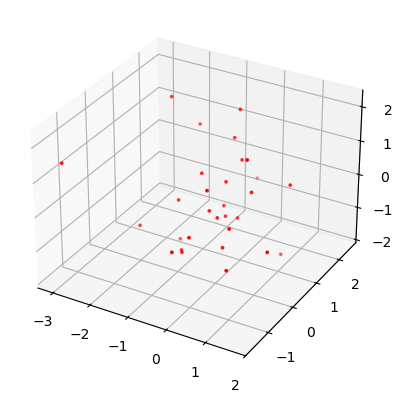

In [16]:
from mpl_toolkits.mplot3d import Axes3D

ex = 0
x = x[ex]
y = y[ex]

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x[:, 0], x[:, 1], x[:, 2], s=3, c='r', marker='o')
plt.show()

In [17]:
def plot_incidence_matrix(im, inverted=True):
    fig, ax = plt.subplots()
    if inverted:
        im = 1 - im
    ax.imshow(im, cmap='hot', vmin=0, vmax=1)
    ax.set_ylabel("Hyperedge")
    ax.set_xlabel("Vertex")
    plt.show()

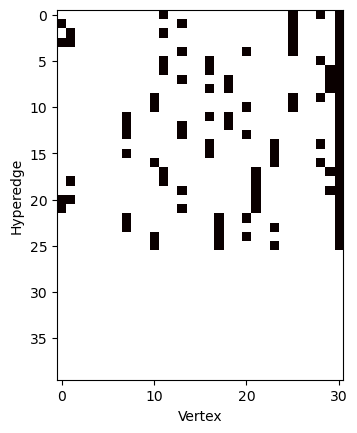

In [18]:
plot_incidence_matrix(y)

In [19]:
def align_incidence_matrix(im_pred, im_true):

    loss, indices = LAP_loss(im_pred, im_true, return_indices=True)
    indices = torch.from_numpy(indices[:,1,...])
    indices = indices.unsqueeze(-1).expand(-1, -1, im_pred.shape[2])

    im_pred_aligned = torch.gather(im_pred, 1, indices)

    return im_pred_aligned, loss, indices

In [20]:
def convert_to_binary(im, threshold=0.5):
    return torch.where(im > threshold, 1, 0)

model.eval()

bs, num_edges, num_nodes = batch[1].shape

if 'refiner' in model.name:
    inputs, truth = batch
    e_t, v_t, i_t = model.net.get_initial(inputs)
    seq = model.net(inputs, e_t, v_t, i_t, t_skip=model.config['iters_total']-1, t_bp=1, save_seq=True)[-1]
    aligned_seq = []
    for s in seq:
        aligned_s, _, _ = align_incidence_matrix(s, batch[1])
        aligned_seq.append(aligned_s)

    seq = torch.stack(aligned_seq, dim=0)
    pred = seq[-1]

    loss = LAP_loss(pred, truth, n=min(model.config['nray'], inputs.size(0)))

elif 'hhrm' in model.name:
    node_feats, im_truth = batch

    hid_state = model.net.get_init_state()

    seq = []

    for s in range(model.net.segments):
        pred, hid_state = model.net(hid_state, node_feats)
        seq.append(pred)

    im_pred = seq[-1]
    im_pred, loss, indices = model.align_incidence_matrix(im_pred, im_truth)

    seq = torch.stack([model.align_incidence_matrix(s, im_truth)[0] for s in seq])

elif model.FM is not None:
    inputs, truth = batch
    num_steps = 15
    im_0 = model.net.get_init_im(bs, num_edges, num_nodes, device=truth.device)
    _, seq, preds = model.sample(im_0, inputs, save_seq=True, num_steps=num_steps) #, method='euler')
    im_pred = seq[-1]
    im_pred, loss, indices = model.align_incidence_matrix(im_pred, truth)
    seq = torch.stack([model.align_incidence_matrix(s, truth)[0] for s in seq])

    ### get the flow matching target as well, for reference
    target_seq = []
    for t in torch.linspace(0, 1, num_steps+1):
        t_, im_t, u_t  = model.sample_location_and_conditional_flow(truth, 
                                                                im_0=seq[0],
                                                                t=t.repeat(bs),
                                                                node_mask=torch.isnan(inputs).any(dim=-1)
                                                                )
        target_seq.append(im_t)
    target_seq = torch.stack(target_seq, dim=0)

else:
    raise NotImplementedError()

In [21]:
# for idx in range(64):
#     im_true = batch[1][idx].cpu().detach().numpy()
#     N_ones = im_true.sum()
#     N_edges = im_true[:, -1].sum()
#     print(f"Hyperedge {idx}: {N_ones} ones, {N_edges} edges")
    

In [23]:
# inputs, truth = batch

# t = torch.tensor([0.2])

# t_, im_t, u_t  = model.sample_location_and_conditional_flow(im_1=truth, im_0=None, t=t, node_mask=torch.isnan(inputs).any(dim=-1))
# pred = model.net(im_t, t, inputs).squeeze(0)

# fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# ax[0].imshow(pred.cpu().detach().numpy(), cmap='bwr', vmin=-1, vmax=1, interpolation='nearest')
# ax[0].set_title(f"Predicted Incidence Matrix at t={t.item():.2f}")
# ax[1].imshow(u_t.squeeze(0).cpu().detach().numpy(), cmap='bwr', vmin=-1, vmax=1, interpolation='nearest')
# ax[1].set_title(f"Flow Matching Target at t={t.item():.2f}")
# plt.show()

In [24]:
# pred_dist = []
# time_dist = []
# targ_dist = []
# for t in torch.linspace(0, 1, 100): 
#     t_, im_t, u_t  = model.sample_location_and_conditional_flow(im_1=truth, im_0=None, t=t.unsqueeze(0), node_mask=torch.isnan(inputs).any(dim=-1))
#     pred = model.net(im_t, t, inputs).squeeze(0)
#     pred_dist.append(pred)
#     time_dist.append(t_)
#     targ_dist.append(u_t)

# pred_dist = torch.stack(pred_dist, dim=0)
# time_dist = torch.stack(time_dist, dim=0)
# targ_dist = torch.stack(targ_dist, dim=0)

In [25]:
# from matplotlib.colors import LogNorm

# fig, ax = plt.subplots(1, 2, figsize=(12, 6))
# ax[0].hist(pred_dist.flatten().cpu().detach().numpy(), bins=50, alpha=0.5, label='Predicted')
# ax[0].hist(targ_dist.flatten().cpu().detach().numpy(), bins=50, alpha=0.5, label='Flow Matching Target')
# ax[0].set_title("Distribution of Predicted and Target Values")
# ax[0].set_xlabel("Value")
# ax[0].set_ylabel("Frequency")
# ax[0].legend()

# x_vals = targ_dist.flatten().cpu().detach().numpy()
# y_vals = pred_dist.flatten().cpu().detach().numpy()
# h = ax[1].hist2d(x_vals, y_vals, bins=100, norm=LogNorm(), cmap='plasma')
# ax[1].plot([-1, 1], [-1, 1], color='red', linestyle='--', label='y=x')
# ax[1].set_xlim([-1, 1])
# ax[1].set_ylim([-1, 1])
# ax[1].set_aspect('equal', adjustable='box')
# ax[1].set_title("Predicted vs Target Values 2D Histogram")
# ax[1].set_xlabel("Target Value")
# ax[1].set_ylabel("Predicted Value")
# # fig.colorbar(h[3], ax=ax[1], label='Counts (log scale)')
# ax[1].legend()
# plt.show()

In [26]:
# ### grid of the distributions for different times
# fig = plt.figure(figsize=(24, 20))
# gs = fig.add_gridspec(10, 10, hspace=0.4, wspace=0.4)
# ax = fig.add_subplot(gs[:, :5])
# for i in range(100):
#     ax = fig.add_subplot(gs[i])
#     ax.hist(pred_dist[i].flatten().cpu().detach().numpy(), bins=50, alpha=0.5, label='Predicted')
#     ax.hist(targ_dist[i].flatten().cpu().detach().numpy(), bins=50, alpha=0.5, label='Flow Matching Target')
#     ax.set_title(f"t={time_dist[i].item():.2f}")
#     ax.set_xlabel("Value")
#     ax.set_ylabel("Frequency")
#     if i==99:
#         ax.legend()

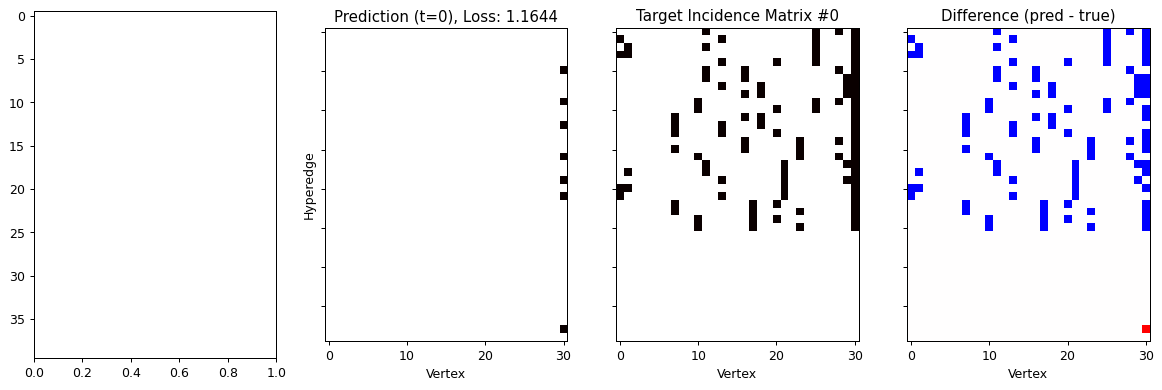

In [27]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(1, 4, figsize=(16, 5), sharey=True, dpi=90)

idx = 0
to_binary = True

def update(timestep):
    '''
    ax[0].clear()
    # Target sequence panel
    # target_im = target_seq[timestep][idx]
    # ax[0].imshow(1 - target_im.cpu().detach().numpy(), cmap='hot', vmin=0, vmax=1, interpolation='nearest')
    velocity = preds[timestep,idx] if timestep < preds.shape[0] else 0*preds[-1,idx]
    ax[0].imshow(1 - velocity[:,:-1].cpu().detach().numpy(), cmap='bwr', vmin=-1, vmax=1, interpolation='nearest')
    ax[0].set_title(f"Predicted v (t={timestep})")
    ax[0].set_ylabel("Hyperedge")
    ax[0].set_xlabel("Vertex")
    '''

    ax[1].clear()
    # Prediction panel
    im_pred = seq[timestep][idx]
    if to_binary:
        im_pred = convert_to_binary(im_pred, 0.5)
    im_pred_np = im_pred.cpu().detach().numpy()
    ax[1].imshow(1 - im_pred_np, cmap='hot', vmin=0, vmax=1, interpolation='nearest')
    ax[1].set_title(f"Prediction (t={timestep}), Loss: {loss[idx].mean():.4f}")
    ax[1].set_ylabel("Hyperedge")
    ax[1].set_xlabel("Vertex")

    ax[2].clear()
    # Target panel
    im_true = batch[1][idx].cpu().detach().numpy()
    ax[2].imshow(1 - im_true, cmap='hot', vmin=0, vmax=1, interpolation='nearest') 
    ax[2].set_title("Target Incidence Matrix #{}".format(idx))
    ax[2].set_xlabel("Vertex")

    ax[3].clear()
    # Difference panel
    diff = im_pred_np - im_true
    ax[3].imshow(diff, cmap='bwr', vmin=-1, vmax=1, interpolation='nearest')
    ax[3].set_title("Difference (pred - true)")
    ax[3].set_xlabel("Vertex")

ani = FuncAnimation(fig, update, frames=torch.arange(0, seq.shape[0], 1), interval=500)

HTML(ani.to_jshtml())

In [28]:
### save ani as GIF
# ani.save(f'{dataset}_animation_{idx}_nonbinary.gif', writer='pillow', fps=2)